In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import KMeansSMOTE
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve, auc, make_scorer
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
import shap

In [3]:
# Load Dataset
df = pd.read_csv("dataset/pd_speech_features.csv", header=1)

# Drop irrelevant columns
df = df.drop(columns=['id'], errors='ignore')

# Convert to numeric
df = df.apply(pd.to_numeric, errors='coerce')

# Drop rows with NaN
df = df.dropna()

In [4]:
df

,gender,PPE,DFA,RPDE,numPulses,numPeriodsPulses,meanPeriodPulses,stdDevPeriodPulses,locPctJitter,locAbsJitter,...,tqwt_kurtosisValue_dec_28,tqwt_kurtosisValue_dec_29,tqwt_kurtosisValue_dec_30,tqwt_kurtosisValue_dec_31,tqwt_kurtosisValue_dec_32,tqwt_kurtosisValue_dec_33,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_35,tqwt_kurtosisValue_dec_36,class
0,1,0.85247,0.71826,0.57227,240,239,0.008064,0.000087,0.00218,0.000018,...,1.5620,2.6445,3.8686,4.2105,5.1221,4.4625,2.6202,3.0004,18.9405,1
1,1,0.76686,0.69481,0.53966,234,233,0.008258,0.000073,0.00195,0.000016,...,1.5589,3.6107,23.5155,14.1962,11.0261,9.5082,6.5245,6.3431,45.1780,1
2,1,0.85083,0.67604,0.58982,232,231,0.008340,0.000060,0.00176,0.000015,...,1.5643,2.3308,9.4959,10.7458,11.0177,4.8066,2.9199,3.1495,4.7666,1
3,0,0.41121,0.79672,0.59257,178,177,0.010858,0.000183,0.00419,0.000046,...,3.7805,3.5664,5.2558,14.0403,4.2235,4.6857,4.8460,6.2650,4.0603,1
4,0,0.32790,0.79782,0.53028,236,235,0.008162,0.002669,0.00535,0.000044,...,6.1727,5.8416,6.0805,5.7621,7.7817,11.6891,8.2103,5.0559,6.1164,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
751,0,0.80903,0.56355,0.28385,417,416,0.004627,0.000052,0.00064,0.000003,...,3.0706,3.0190,3.1212,2.4921,3.5844,3.5400,3.3805,3.2003,6.8671,0
752,0,0.16084,0.56499,0.59194,415,413,0.004550,0.000220,0.00143,0.000006,...,1.9704,1.7451,1.8277,2.4976,5.2981,4.2616,6.3042,10.9058,28.4170,0
753,0,0.88389,0.72335,0.46815,381,380,0.005069,0.000103,0.00076,0.000004,...,51.5607,44.4641,26.1586,6.3076,2.8601,2.5361,3.5377,3.3545,5.0424,0
754,0,0.83782,0.74890,0.49823,340,339,0.005679,0.000055,0.00092,0.000005,...,19.1607,12.8312,8.9434,2.2044,1.9496,1.9664,2.6801,2.8332,3.7131,0


In [5]:
# Feature Preparation
X = df.drop(columns='class')
y = df['class']

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (756, 753)
Shape of y: (756,)


In [ ]:
# Standardization (mean=0, std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

C:\Users\Pc Dayan\AppData\Local\Temp\ipykernel_7424\1895004357.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette="Purples")


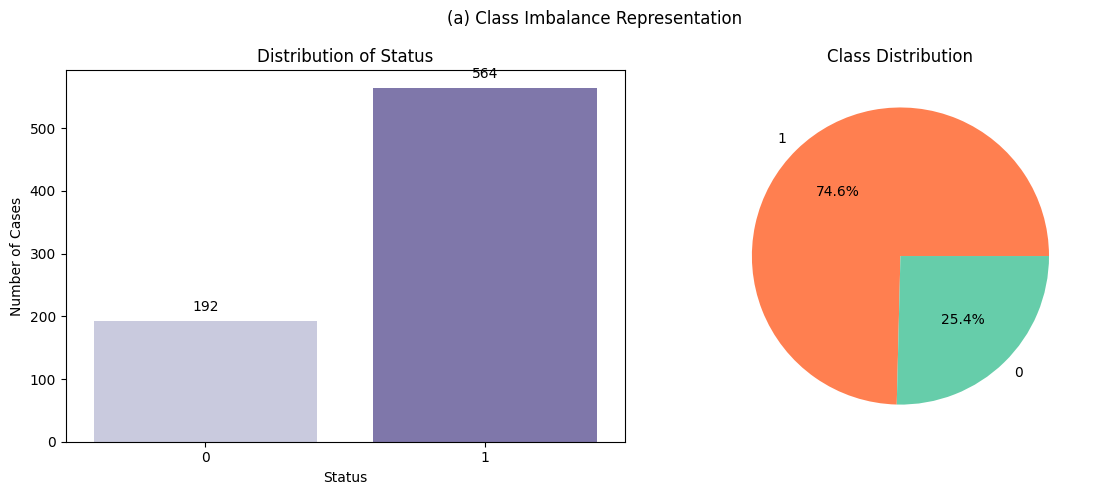

In [5]:
# (a) Class Imbalance Representation
plt.figure(figsize=(12, 5))

# Bar plot
plt.subplot(1, 2, 1)
sns.countplot(x=y, palette="Purples")
plt.title("Distribution of Status")
plt.xlabel("Status")
plt.ylabel("Number of Cases")
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='center', fontsize=10, color='black', xytext=(0, 10),
                       textcoords='offset points')

# Pie chart
plt.subplot(1, 2, 2)
y_counts = y.value_counts()
plt.pie(y_counts, labels=y_counts.index, autopct='%1.1f%%', colors=["coral", "mediumaquamarine"])
plt.title("Class Distribution")

plt.suptitle("(a) Class Imbalance Representation", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Class Balancing
kmeans_smote = KMeansSMOTE(random_state=42)
X_resampled, y_resampled = kmeans_smote.fit_resample(X_scaled, y)

C:\Users\Pc Dayan\AppData\Local\Temp\ipykernel_7424\2389196385.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_resampled, palette=["skyblue", "lightcoral"])


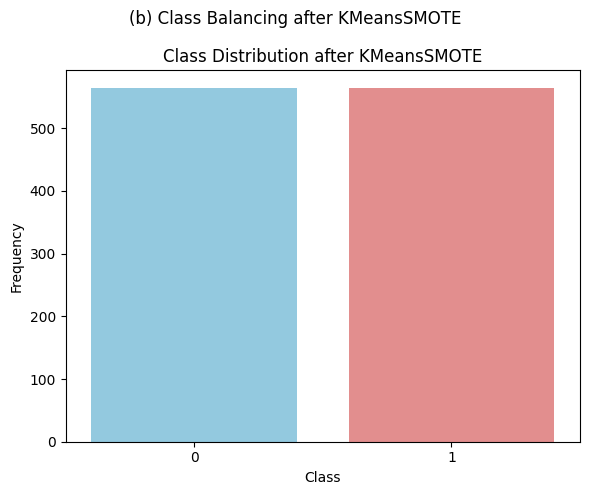

In [ ]:
# (b) Class Balancing Representation
plt.figure(figsize=(6, 5))
sns.countplot(x=y_resampled, palette=["skyblue", "lightcoral"])
plt.title("Class Distribution after KMeansSMOTE")
plt.xlabel("Class")
plt.ylabel("Frequency")
plt.suptitle("(b) Class Balancing after KMeansSMOTE", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Feature Selection (RFE) + Logistic Model
lr = LogisticRegression(max_iter=1000, solver='liblinear')
rfe = RFE(estimator=lr, n_features_to_select=50)
X_rfe = rfe.fit_transform(X_resampled, y_resampled)

In [ ]:
#  Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_rfe, y_resampled, test_size=0.2, random_state=42)

In [ ]:
# Model Training & Evaluation
model = LogisticRegression(max_iter=1000, solver='liblinear')
model.fit(X_train, y_train)

# Predictions and evaluation
y_pred = model.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]))

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.95      0.95       109
           1       0.96      0.96      0.96       117

    accuracy                           0.96       226
   macro avg       0.96      0.96      0.96       226
weighted avg       0.96      0.96      0.96       226

Confusion Matrix:
 [[104   5]
 [  5 112]]
ROC AUC Score: 0.9880028228652082


In [ ]:
# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score, average='macro'),
    'recall': make_scorer(recall_score, average='macro'),
    'f1': make_scorer(f1_score, average='macro'),
    'roc_auc': 'roc_auc'
}

# Proposed model (Model Training & Evaluation)
proposed_model = LogisticRegression(max_iter=1000, solver='liblinear')
cv_results = cross_validate(proposed_model, X_rfe, y_resampled, cv=cv, scoring=scoring, return_train_score=True)

# Print CV results
print("Cross-Validation Results:\n")
print(f"{'Metric':<20} {'Mean Score (%)':>15}")
print("-" * 35)
print(f"{'Accuracy':<20} {cv_results['test_accuracy'].mean() * 100:>15.2f}")
print(f"{'Precision (Macro)':<20} {cv_results['test_precision'].mean() * 100:>15.2f}")
print(f"{'Recall (Macro)':<20} {cv_results['test_recall'].mean() * 100:>15.2f}")
print(f"{'F1-Score (Macro)':<20} {cv_results['test_f1'].mean() * 100:>15.2f}")
print(f"{'ROC AUC':<20} {cv_results['test_roc_auc'].mean() * 100:>15.2f}")

Cross-Validation Results:

Metric                Mean Score (%)
-----------------------------------
Accuracy                       95.48
Precision (Macro)              95.52
Recall (Macro)                 95.48
F1-Score (Macro)               95.48
ROC AUC                        99.12


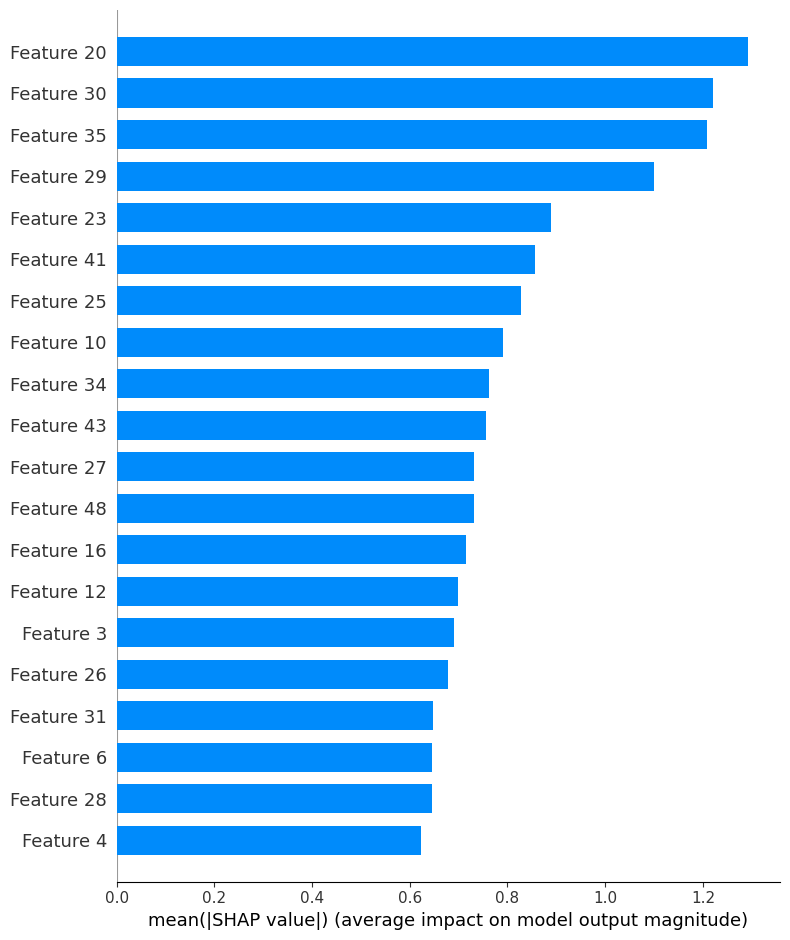

In [32]:
# SHAP Explainability
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

# SHAP summary plot (bar type)
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [33]:
# Extract mean absolute SHAP values for each feature
mean_shap_values = np.abs(shap_values.values).mean(axis=0)

# Get top 10 feature indices by importance
top_indices = np.argsort(mean_shap_values)[-10:][::-1]
top_importances = mean_shap_values[top_indices]

# Create and display as a DataFrame
top_features_df = pd.DataFrame({
    "Feature Index Value": top_indices,
    "Feature Importance Value": top_importances
})

# Round values for clean display
top_features_df["Feature Importance Value"] = top_features_df["Feature Importance Value"].round(6)

print("Top 10 Feature Index and Importance Values:")
print(top_features_df.to_string(index=False))

Top 10 Feature Index and Importance Values:
 Feature Index Value  Feature Importance Value
                  20                  1.293061
                  30                  1.220643
                  35                  1.208106
                  29                  1.100593
                  23                  0.888805
                  41                  0.855916
                  25                  0.828233
                  10                  0.790073
                  34                  0.761783
                  43                  0.755452


In [ ]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_rfe, y_resampled, test_size=0.2, random_state=42)

# Proposed model: RFE + Logistic Regression
proposed_model = LogisticRegression(max_iter=1000, solver='liblinear')
proposed_model.fit(X_train, y_train)

# Train other models on full feature set
svc_model = SVC(probability=True, random_state=42)
svc_model.fit(X_train, y_train)

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

mlp_model = MLPClassifier(max_iter=1000, activation="logistic", random_state=42)
mlp_model.fit(X_train, y_train)

xgb_model = XGBClassifier(eval_metric='logloss', use_label_encoder=False, random_state=42)
xgb_model.fit(X_train, y_train)

cat_model = CatBoostClassifier(verbose=0, random_state=42)
cat_model.fit(X_train, y_train)

knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)

# List of all classifiers
models = {
    "Support Vector Classifier": svc_model,
    "Random Forest Classifier": rf_model,
    "MLP Classifier": mlp_model,
    "XGBoost Classifier": xgb_model,
    "CatBoost Classifier": cat_model,
    "KNN Classifier": knn_model,
    "Proposed Classifier (RFE + Logistic Regression)": proposed_model
}

# Initialize for performance
results = []

for name, model in models.items():
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred) * 100
    test_acc = accuracy_score(y_test, y_test_pred) * 100
    precision = precision_score(y_test, y_test_pred, average="macro") * 100
    recall = recall_score(y_test, y_test_pred, average="macro") * 100
    f1 = f1_score(y_test, y_test_pred, average="macro") * 100

    results.append({
        "ML Model": name,
        "Training Accuracy (%)": round(train_acc, 2),
        "Testing Accuracy (%)": round(test_acc, 2),
        "Precision Score (%)": round(precision, 2),
        "Recall Score (%)": round(recall, 2),
        "F1 Score (%)": round(f1, 2)
    })

df_results = pd.DataFrame(results)
df_results

c:\Users\Pc Dayan\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:55:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,ML Model,Training Accuracy (%),Testing Accuracy (%),Precision Score (%),Recall Score (%),F1 Score (%)
0,Support Vector Classifier,96.78,94.69,95.01,94.56,94.66
1,Random Forest Classifier,100.00,91.15,91.32,91.05,91.12
2,MLP Classifier,100.00,95.13,95.14,95.11,95.13
3,XGBoost Classifier,100.00,92.92,93.22,92.79,92.88
4,CatBoost Classifier,100.00,93.81,93.99,93.70,93.78
5,KNN Classifier,96.67,92.04,92.21,91.93,92.00
6,Proposed Classifier (RFE + Logistic Regression),97.56,95.58,95.57,95.57,95.57


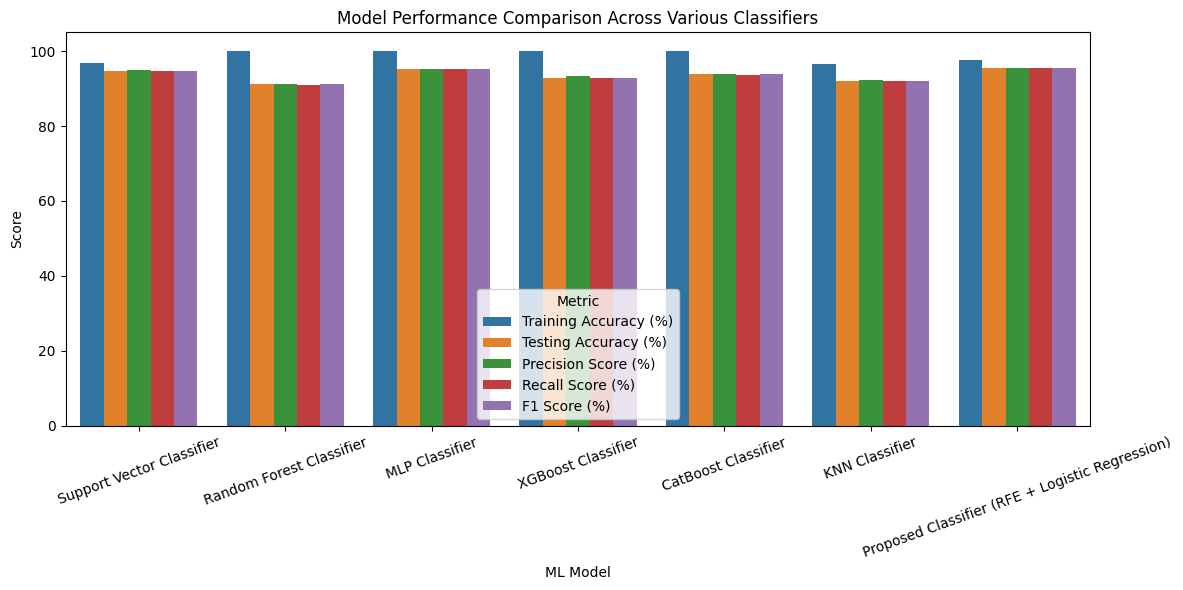

In [12]:
# Plotting Performances
df_melted = df_results.melt(id_vars='ML Model', 
                            value_vars=['Training Accuracy (%)', 'Testing Accuracy (%)',
                                        'Precision Score (%)', 'Recall Score (%)', 'F1 Score (%)'],
                            var_name='Metric', value_name='Score')

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x='ML Model', y='Score', hue='Metric', data=df_melted)
plt.title("Model Performance Comparison Across Various Classifiers")
plt.xticks(rotation=20)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

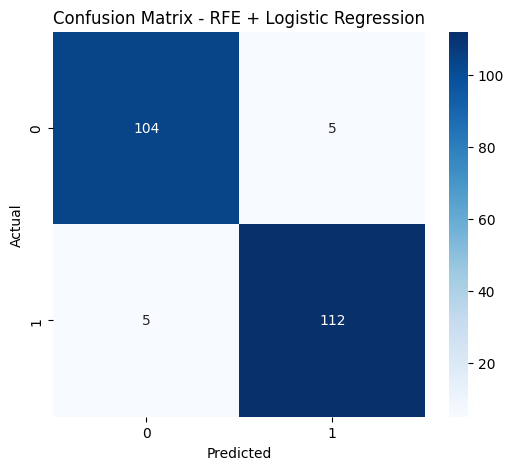

In [13]:
# Confusion matrix for Proposed Model (RFE + Logistic Regression)
proposed_y_pred = proposed_model.predict(X_test)
proposed_cm = confusion_matrix(y_test, proposed_y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(proposed_cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - RFE + Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

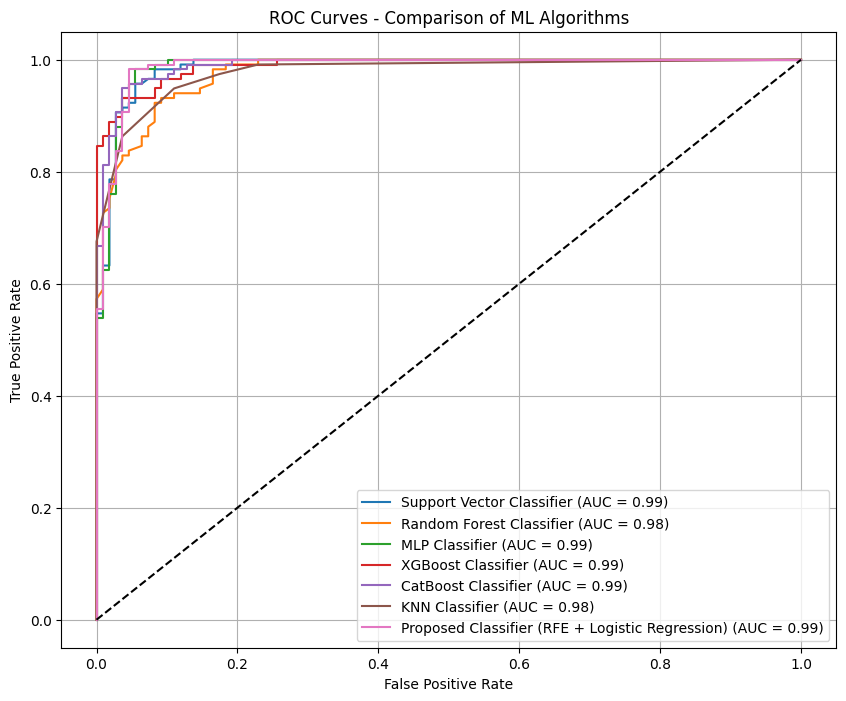

In [14]:
# ROC curve comparison
plt.figure(figsize=(10, 8))
for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Comparison of ML Algorithms")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

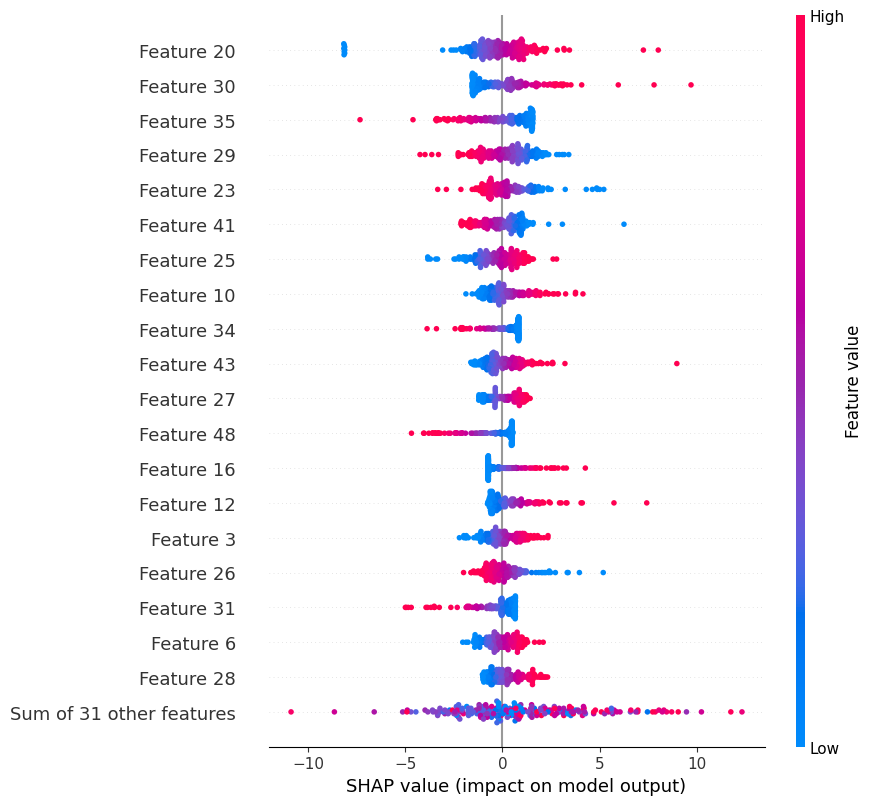

In [15]:
# SHAP Feature Importance for Proposed Model (RFE + Logistic Regression)
explainer = shap.Explainer(proposed_model, X_train)
shap_values = explainer(X_test)

# Summary plot (top 20 features)
shap.plots.beeswarm(shap_values, max_display=20)

In [ ]:
from sklearn.decomposition import PCA

# PCA for dimensionality reduction
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_resampled)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_pca, y_resampled, test_size=0.2, random_state=42)

# Train Models
models = {
    "Support Vector Classifier": SVC(probability=True, random_state=42),
    "Random Forest Classifier": RandomForestClassifier(random_state=42),
    "MLP Classifier": MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, activation='relu', solver='adam', random_state=42),
    "XGBoost Classifier": XGBClassifier(eval_metric='logloss', use_label_encoder=False, random_state=42),
    "CatBoost Classifier": CatBoostClassifier(verbose=0, random_state=42),
    "KNN Classifier": KNeighborsClassifier(),
    "Proposed Classifier (PCA with Logistic Regression)": LogisticRegression(max_iter=1000, solver='liblinear')
}

results = []
probabilities = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    train_acc = accuracy_score(y_train, y_train_pred) * 100
    test_acc = accuracy_score(y_test, y_test_pred) * 100
    precision = precision_score(y_test, y_test_pred, average='macro') * 100
    recall = recall_score(y_test, y_test_pred, average='macro') * 100
    f1 = f1_score(y_test, y_test_pred, average='macro') * 100
    
    results.append({
        "ML Model": name,
        "Training Accuracy (%)": round(train_acc, 2),
        "Testing Accuracy (%)": round(test_acc, 2),
        "Precision Score (%)": round(precision, 2),
        "Recall Score (%)": round(recall, 2),
        "F1 Score (%)": round(f1, 2)
    })
    
    if hasattr(model, "predict_proba"):
        probabilities[name] = model.predict_proba(X_test)[:, 1]

# Results DataFrame
df_results = pd.DataFrame(results)
df_results

c:\Users\Pc Dayan\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:58:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,ML Model,Training Accuracy (%),Testing Accuracy (%),Precision Score (%),Recall Score (%),F1 Score (%)
0,Support Vector Classifier,92.90,89.38,90.12,89.15,89.28
1,Random Forest Classifier,100.00,89.82,90.91,89.54,89.70
2,MLP Classifier,100.00,93.81,93.80,93.80,93.80
3,XGBoost Classifier,100.00,91.59,91.72,91.50,91.57
4,CatBoost Classifier,100.00,89.38,89.77,89.21,89.31
5,KNN Classifier,94.12,89.82,89.94,89.73,89.79
6,Proposed Classifier (PCA with Logistic Regress...,92.02,87.61,87.59,87.63,87.60
